# Short-Term Event Study: Minutely Industry Returns
## Trump @-mentioned Company Tweets — Event Window [−60, +60] minutes

| Item | Detail |
|------|--------|
| Data frequency | 1-minute returns |
| Files | 233 (one per tweet × industry, same as long-term) |
| Naming | `{tweet_id}_minutely_{prefix}_panel.csv` |
| Estimation window | t ∈ [−60, −1] → simple mean as expected return |
| Event window | t ∈ [0, +60] |
| Expected return model | **Mean model** (no market factor — intraday) |
| AR | $AR_{i,t} = R_{i,t} - \\bar{R}_{i,[-60,-1]}$ |
| AAR | $AAR_t = \\frac{1}{N}\\sum_i AR_{i,t}$ |
| CAAR | $CAAR_{[0,t]} = \sum_{\tau=0}^{t} AAR_{\tau}$ |

---
## Step 0: Setup

In [ ]:
import os, glob, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from itertools import combinations
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore')

# ── UPDATE THESE PATHS ─────────────────────────────────────────────────────
MINUTELY_DIR  = "MINUTELY EVENT STUDY PANELS BY SINGLE INDUSTRY"
LONG_TERM_CSV = "AAR_CAAR_treatment.csv"  # as exported by long_term_return.ipynb

# ── Windows ────────────────────────────────────────────────────────────────
EST_START, EST_END =  -60, -1
EVT_START, EVT_END =    0, 60
event_mins = list(range(EVT_START, EVT_END + 1))

# ── Industry prefix → label ────────────────────────────────────────────────
INDUSTRY_MAP = {
    'Airl': 'Airlines & Travel',
    'Auto': 'Automobiles',
    'Chem': 'Chemicals',
    'Cons': 'Construction',
    'Defe': 'Defense & Aerospace',
    'Fina': 'Financials (Banks)',
    'News': 'News & Publishing',
    'Oil':  'Oil & Gas',
    'Semi': 'Semiconductors',
    'Tech': 'Technology & Internet',
}
PREFIXES   = list(INDUSTRY_MAP.keys())
IND_LABELS = INDUSTRY_MAP

colors    = plt.cm.tab10(np.linspace(0, 1, 10))
COLOR_MAP = {p: colors[i] for i, p in enumerate(PREFIXES)}

def sig_stars(p):
    if pd.isna(p): return ''
    if p < 0.01:   return '***'
    if p < 0.05:   return '**'
    if p < 0.10:   return '*'
    return ''

print('Setup complete.')
print(f'  Minutely dir : {MINUTELY_DIR}')
print(f'  Estimation   : t in [{EST_START}, {EST_END}]')
print(f'  Event window : t in [{EVT_START}, {EVT_END}]')

Setup complete.
  Minutely dir : /Users/feifeifeifeifeifeifeidemac/gsfm/calculation/MINUTELY EVENT STUDY PANELS BY SINGLE INDUSTRY
  Estimation   : t in [-60, -1]
  Event window : t in [0, 60]


---
## Step 1: Load Files

In [2]:
def get_ret_col(df):
    cols = [c for c in df.columns
            if 'return' in c.lower() and c.lower() != 't']
    return cols[0] if cols else None

def load_panel(fpath):
    df = pd.read_csv(fpath)
    df['t'] = pd.to_numeric(df['t'], errors='coerce')
    return df.dropna(subset=['t']).set_index('t').sort_index()

panels  = {p: [] for p in PREFIXES}
skipped = []

for prefix in PREFIXES:
    files = sorted(glob.glob(
        os.path.join(MINUTELY_DIR, f'*_minutely_{prefix}_panel.csv')))
    for f in files:
        m   = re.match(r'(\d+)_minutely_.+_panel\.csv', os.path.basename(f))
        tid = m.group(1) if m else os.path.basename(f)
        df  = load_panel(f)
        rc  = get_ret_col(df)
        if rc is None:
            skipped.append(f); continue
        panels[prefix].append((tid, df, rc))

total = sum(len(v) for v in panels.values())
print(f'Loaded {total} files  |  Skipped: {len(skipped)}')
print()
print(f"{'Industry':<35} {'N':>5}  Note")
print('-' * 55)
for p in PREFIXES:
    n    = len(panels[p])
    note = 'N=1 — unreliable (data limitation)' if n == 1 else \
           'N=0 — no data' if n == 0 else ''
    print(f"{IND_LABELS[p]:<35} {n:>5}  {note}")

Loaded 233 files  |  Skipped: 0

Industry                                N  Note
-------------------------------------------------------
Airlines & Travel                       6  
Automobiles                            14  
Chemicals                               1  N=1 — unreliable (data limitation)
Construction                            1  N=1 — unreliable (data limitation)
Defense & Aerospace                    10  
Financials (Banks)                      6  
News & Publishing                      91  
Oil & Gas                               1  N=1 — unreliable (data limitation)
Semiconductors                         16  
Technology & Internet                  87  


---
## Step 2: Compute Expected Return and Abnormal Returns

**Mean model** — standard for intraday event studies (Busse & Green 2002):

$$\bar{R}_i = \frac{1}{60}\sum_{t=-60}^{-1} R_{i,t} \qquad AR_{i,t} = R_{i,t} - \bar{R}_i$$

In [3]:
ar_matrix = {p: {t: [] for t in event_mins} for p in PREFIXES}
est_log   = []
n_skip    = 0

for prefix in PREFIXES:
    for tid, df, rc in panels[prefix]:
        est = df.loc[(df.index >= EST_START) & (df.index <= EST_END), rc].dropna()
        if len(est) < 10:
            n_skip += 1; continue
        mu = est.mean()
        est_log.append({'prefix': prefix, 'industry': IND_LABELS[prefix],
                        'mu_pct': mu*100, 'sd_pct': est.std(ddof=1)*100,
                        'n_est': len(est)})
        for t in event_mins:
            if t not in df.index: continue
            r = df.loc[t, rc]
            if pd.isna(r): continue
            ar_matrix[prefix][t].append(float(r) - mu)

est_df   = pd.DataFrame(est_log)
total_ar = sum(len(v) for p in PREFIXES for v in ar_matrix[p].values())
print(f'AR computed: {total_ar:,}  |  Skipped (< 10 est obs): {n_skip}')
print()
print(f"{'Industry':<35} {'N events':>9} {'Mean mu (%)':>13} {'Mean SD (%)':>13}")
print('-' * 74)
for p in PREFIXES:
    sub = est_df[est_df['prefix'] == p]
    if sub.empty:
        print(f"{IND_LABELS[p]:<35} {'0':>9}")
    else:
        print(f"{IND_LABELS[p]:<35} {len(sub):>9} "
              f"{sub['mu_pct'].mean():>+12.5f}%  "
              f"{sub['sd_pct'].mean():>12.5f}%")

AR computed: 14,213  |  Skipped (< 10 est obs): 0

Industry                             N events   Mean mu (%)   Mean SD (%)
--------------------------------------------------------------------------
Airlines & Travel                           6     +0.00029%       0.03783%
Automobiles                                14     +0.00306%       0.03585%
Chemicals                                   1     -0.00219%       0.02018%
Construction                                1     -0.00038%       0.07637%
Defense & Aerospace                        10     -0.00057%       0.03976%
Financials (Banks)                          6     +0.00034%       0.06569%
News & Publishing                          91     +0.00060%       0.05847%
Oil & Gas                                   1     +0.00143%       0.02168%
Semiconductors                             16     +0.00140%       0.04611%
Technology & Internet                      87     +0.00058%       0.04330%


---
## Step 3: Compute AAR and CAAR

In [4]:
results = {}

for prefix in PREFIXES:
    rows = []
    for t in event_mins:
        ars = ar_matrix[prefix][t]
        n   = len(ars)
        if n == 0:
            rows.append(dict(t=t, AAR=np.nan, SE=np.nan,
                             N=0, t_stat=np.nan, p_value=np.nan))
            continue
        aar = np.mean(ars)
        se  = np.std(ars, ddof=1) / np.sqrt(n)
        tst = aar / se if se > 0 else np.nan
        pv  = 2*stats.t.sf(abs(tst), df=n-1) if not np.isnan(tst) else np.nan
        rows.append(dict(t=t, AAR=aar, SE=se, N=n, t_stat=tst, p_value=pv))

    df_r             = pd.DataFrame(rows).set_index('t')
    df_r['CAAR']     = df_r['AAR'].cumsum()
    df_r['CAAR_SE']  = np.sqrt(df_r['SE'].pow(2).cumsum().replace(0, np.nan))
    df_r['CAAR_t']   = df_r['CAAR'] / df_r['CAAR_SE']
    df_r['CAAR_p']   = df_r.apply(
        lambda r: 2*stats.t.sf(abs(r['CAAR_t']), df=max(int(r['N'])-1, 1))
        if not np.isnan(r.get('CAAR_t', np.nan)) else np.nan, axis=1)
    results[prefix]  = df_r

print(f"{'Industry':<35} {'N':>5} {'AAR(t=0)%':>12} {'':>4} {'CAAR[0,60]%':>13} {'':>4}")
print('-' * 78)
for p in PREFIXES:
    df_r = results[p]
    n    = int(df_r.loc[0,'N'])            if 0       in df_r.index else 0
    a0   = df_r.loc[0,'AAR']*100           if 0       in df_r.index else np.nan
    p0   = df_r.loc[0,'p_value']           if 0       in df_r.index else np.nan
    c60  = df_r.loc[EVT_END,'CAAR']*100    if EVT_END in df_r.index else np.nan
    cp60 = df_r.loc[EVT_END,'CAAR_p']      if EVT_END in df_r.index else np.nan
    print(f"{IND_LABELS[p]:<35} {n:>5} "
          f"{a0:>+11.4f}%  {sig_stars(p0):>3}  "
          f"{c60:>+11.4f}%  {sig_stars(cp60):>3}")
print('\n* p<0.10  ** p<0.05  *** p<0.01')

Industry                                N    AAR(t=0)%        CAAR[0,60]%     
------------------------------------------------------------------------------
Airlines & Travel                       6     -0.0006%           -0.0101%     
Automobiles                            14     -0.0251%           -0.3654%   **
Chemicals                               1     -0.0075%           -0.0553%     
Construction                            1     -0.0769%           +0.1727%     
Defense & Aerospace                    10     -0.0047%           -0.0243%     
Financials (Banks)                      6     -0.0138%           -0.8567%  ***
News & Publishing                      91     +0.0013%           +0.0227%     
Oil & Gas                               1     -0.0014%           -0.5726%     
Semiconductors                         16     -0.0038%           -0.2789%     
Technology & Internet                  87     -0.0029%           -0.1260%   **

* p<0.10  ** p<0.05  *** p<0.01


---
## Step 4: Visualizations
### Figure 1 — AAR Heatmap (every 5 minutes)

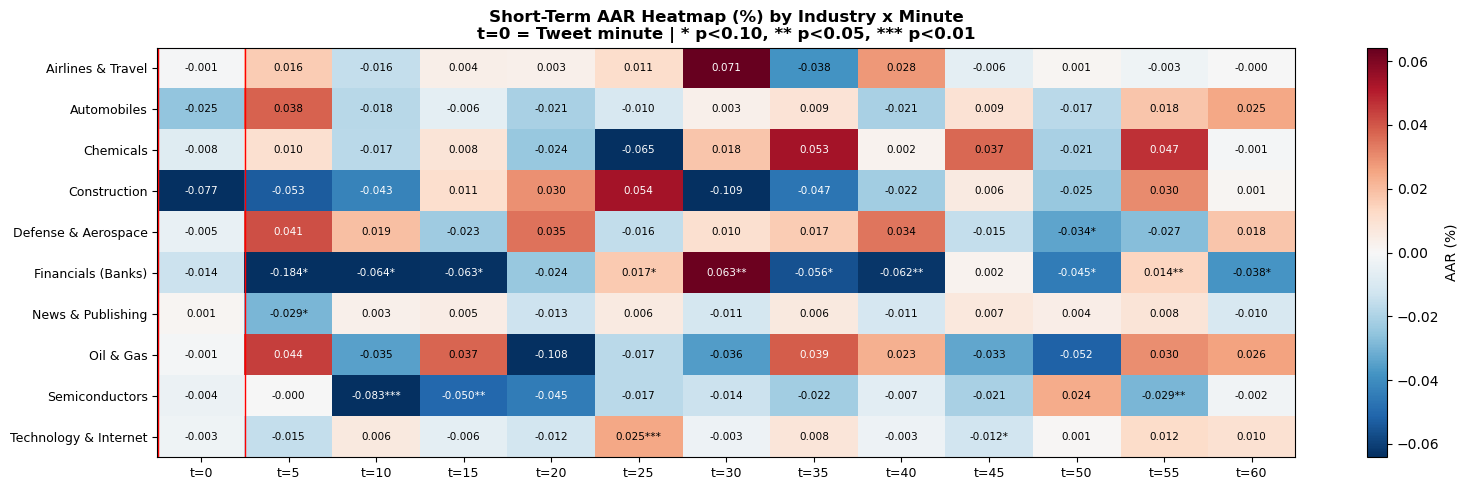

Saved: short_term_AAR_heatmap.png


In [5]:
hmap_mins = list(range(0, 61, 5))
aar_mat   = np.full((len(PREFIXES), len(hmap_mins)), np.nan)
pval_mat  = np.full((len(PREFIXES), len(hmap_mins)), np.nan)

for i, p in enumerate(PREFIXES):
    for j, t in enumerate(hmap_mins):
        if t in results[p].index and results[p].loc[t,'N'] > 0:
            aar_mat[i,j]  = results[p].loc[t,'AAR'] * 100
            pval_mat[i,j] = results[p].loc[t,'p_value']

fig, ax = plt.subplots(figsize=(16, 5))
vmax = np.nanpercentile(np.abs(aar_mat), 95)
im   = ax.imshow(aar_mat, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)

for i in range(len(PREFIXES)):
    for j in range(len(hmap_mins)):
        v = aar_mat[i,j]
        if not np.isnan(v):
            s = sig_stars(pval_mat[i,j])
            c = 'white' if abs(v) > vmax * 0.6 else 'black'
            ax.text(j, i, f'{v:.3f}{s}',
                    ha='center', va='center', fontsize=7.5, color=c)

ax.set_xticks(range(len(hmap_mins)))
ax.set_xticklabels([f't={t}' for t in hmap_mins], fontsize=9)
ax.set_yticks(range(len(PREFIXES)))
ax.set_yticklabels([IND_LABELS[p] for p in PREFIXES], fontsize=9)
ax.axvline(-0.5, color='red', linewidth=2.5)
ax.axvline( 0.5, color='red', linewidth=1.0)
ax.set_title(
    'Short-Term AAR Heatmap (%) by Industry x Minute\n'
    't=0 = Tweet minute | * p<0.10, ** p<0.05, *** p<0.01',
    fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, label='AAR (%)')
plt.tight_layout()
plt.savefig('short_term_AAR_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: short_term_AAR_heatmap.png')

### Figure 2 — CAAR by Industry (2x5 grid)

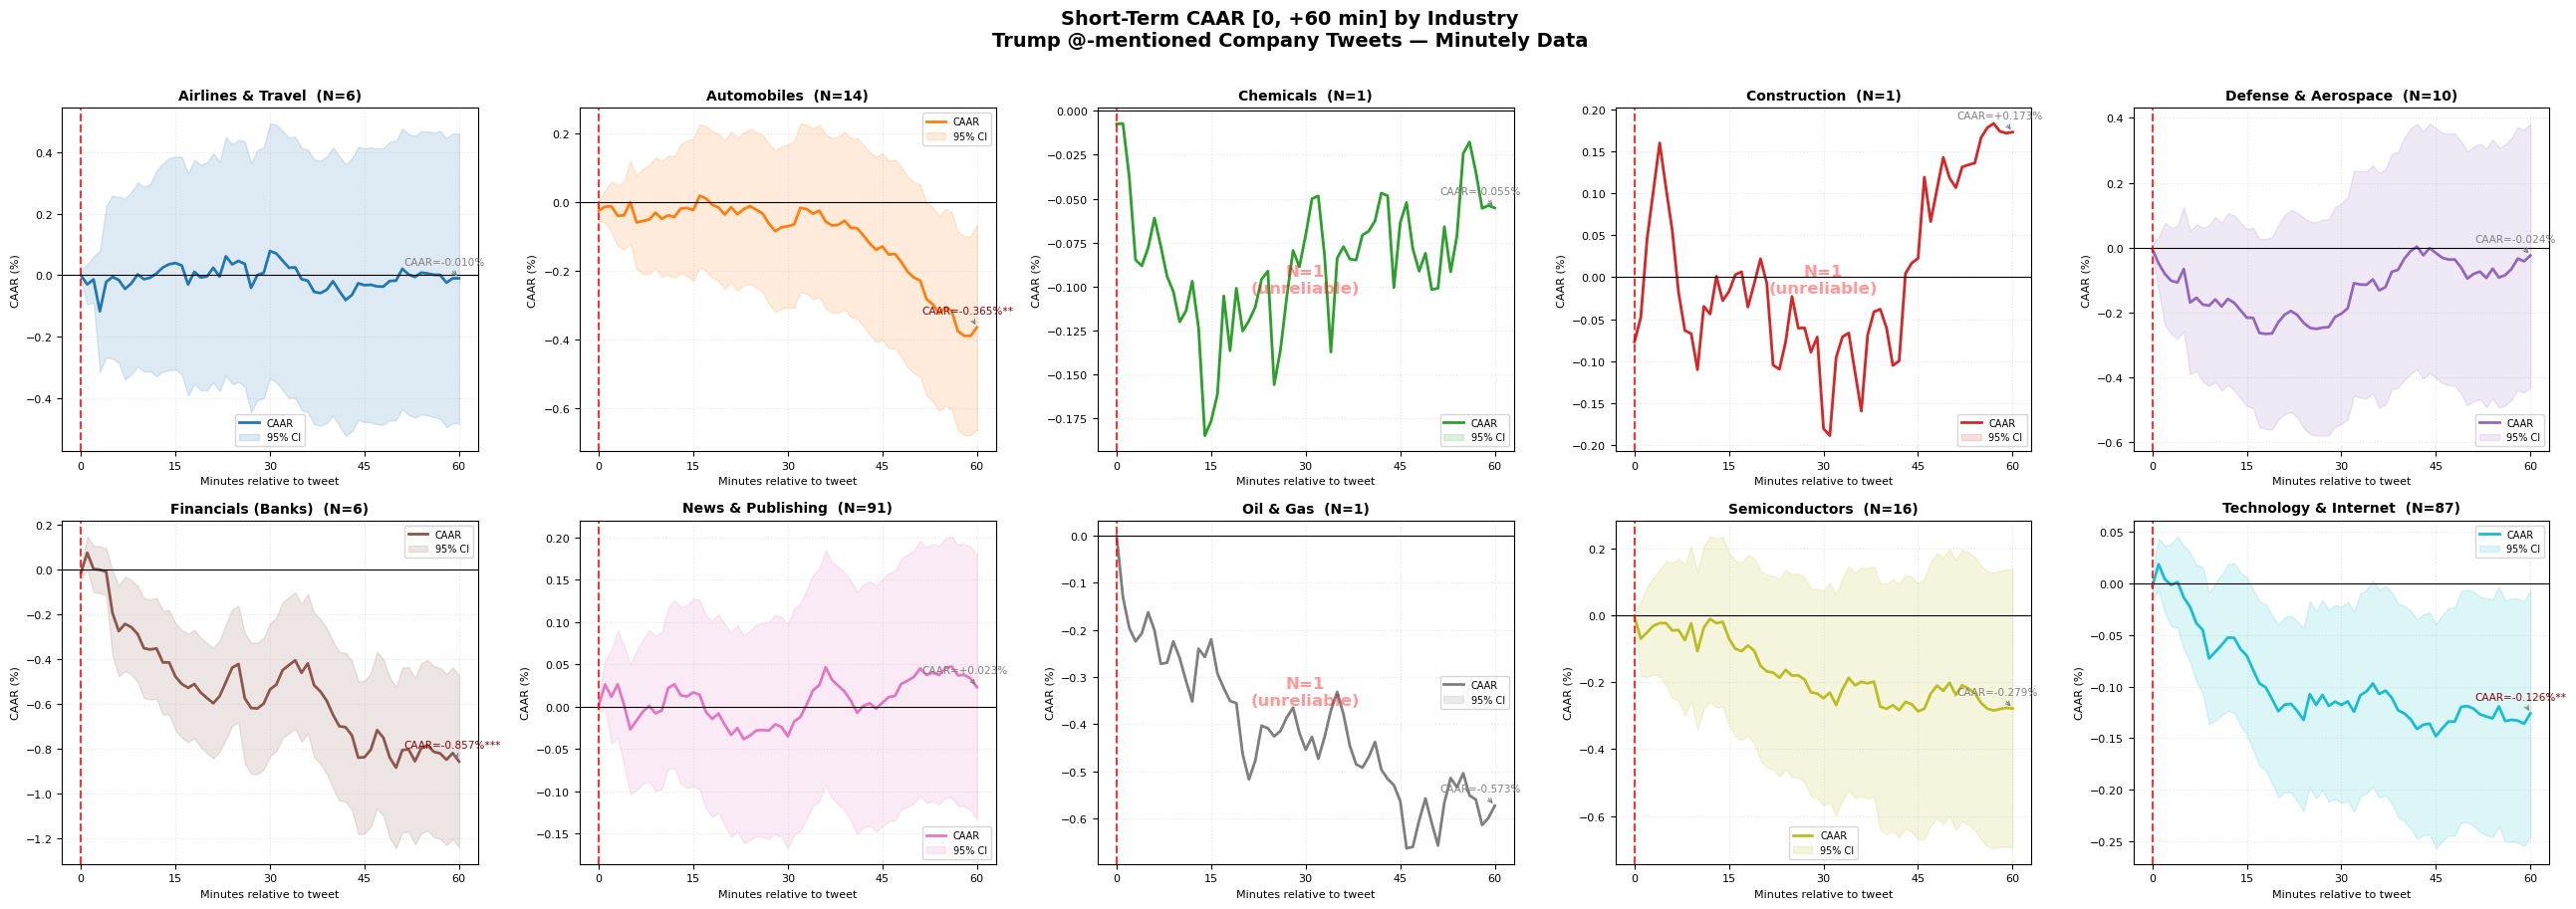

Saved: short_term_CAAR_all_industries.png


In [6]:
fig, axes = plt.subplots(2, 5, figsize=(26, 9))
axes = axes.flatten()

for idx, p in enumerate(PREFIXES):
    ax    = axes[idx]
    df_r  = results[p]
    color = COLOR_MAP[p]
    t_v   = df_r.index.tolist()
    caar  = df_r['CAAR'].values * 100
    cse   = df_r['CAAR_SE'].fillna(0).values * 100
    n_ev  = int(df_r.loc[EVT_END,'N']) if EVT_END in df_r.index else 0

    ax.plot(t_v, caar, color=color, linewidth=2, label='CAAR')
    ax.fill_between(t_v, caar - 1.96*cse, caar + 1.96*cse,
                    color=color, alpha=0.15, label='95% CI')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='red',   linewidth=1.5, linestyle='--', alpha=0.8)

    c60  = df_r.loc[EVT_END,'CAAR']*100 if EVT_END in df_r.index else np.nan
    cp60 = df_r.loc[EVT_END,'CAAR_p']   if EVT_END in df_r.index else np.nan
    if not np.isnan(c60):
        clr = 'darkred' if sig_stars(cp60) else 'gray'
        ax.annotate(f'CAAR={c60:+.3f}%{sig_stars(cp60)}',
                    xy=(EVT_END, c60), xytext=(-40, 10),
                    textcoords='offset points', fontsize=7.5, color=clr,
                    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

    ax.set_title(f'{IND_LABELS[p]}  (N={n_ev})', fontsize=10, fontweight='bold')
    ax.set_xlabel('Minutes relative to tweet', fontsize=8)
    ax.set_ylabel('CAAR (%)', fontsize=8)
    ax.set_xticks(range(0, 61, 15))
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.3, linestyle=':')
    ax.legend(fontsize=7)

    if n_ev <= 1:
        ax.text(0.5, 0.5, 'N=1\n(unreliable)',
                transform=ax.transAxes, ha='center', va='center',
                fontsize=12, color='red', alpha=0.4, fontweight='bold')

fig.suptitle(
    'Short-Term CAAR [0, +60 min] by Industry\n'
    'Trump @-mentioned Company Tweets — Minutely Data',
    fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('short_term_CAAR_all_industries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: short_term_CAAR_all_industries.png')

### Figure 3 — CAAR Overlay (all industries)

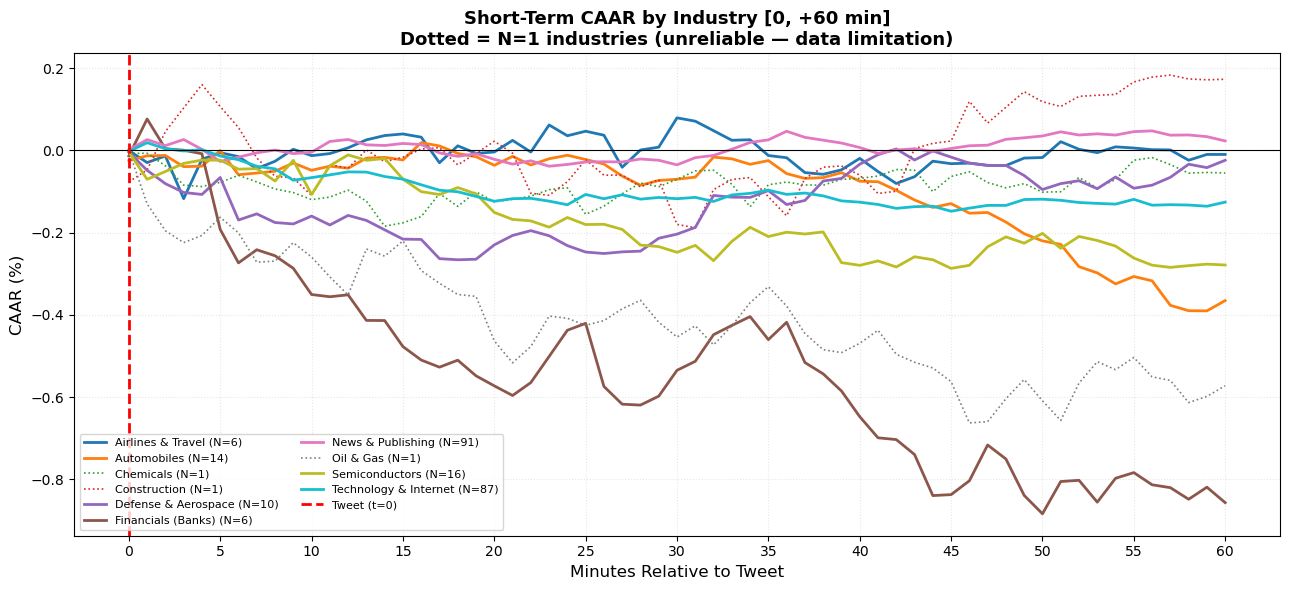

Saved: short_term_CAAR_overlay.png


In [7]:
fig, ax = plt.subplots(figsize=(13, 6))

for p in PREFIXES:
    df_r = results[p]
    n_ev = int(df_r.loc[EVT_END,'N']) if EVT_END in df_r.index else 0
    if n_ev == 0: continue
    caar = df_r['CAAR'].values * 100
    lw   = 1.2 if n_ev == 1 else 2.0
    ls   = ':' if n_ev == 1 else '-'
    ax.plot(df_r.index.tolist(), caar,
            color=COLOR_MAP[p], linewidth=lw, linestyle=ls,
            label=f'{IND_LABELS[p]} (N={n_ev})')

ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='red',   linewidth=2, linestyle='--', label='Tweet (t=0)')
ax.set_xlabel('Minutes Relative to Tweet', fontsize=12)
ax.set_ylabel('CAAR (%)', fontsize=12)
ax.set_title(
    'Short-Term CAAR by Industry [0, +60 min]\n'
    'Dotted = N=1 industries (unreliable — data limitation)',
    fontsize=13, fontweight='bold')
ax.set_xticks(range(0, 61, 5))
ax.grid(alpha=0.3, linestyle=':')
ax.legend(loc='best', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('short_term_CAAR_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: short_term_CAAR_overlay.png')

---
## Step 5: Cross-Industry Significance Tests
### 5a — Kruskal-Wallis at each 5-minute mark

In [8]:
test_mins = list(range(0, 61, 5))
kw_rows   = []

for t in test_mins:
    groups = [ar_matrix[p][t] for p in PREFIXES if len(ar_matrix[p][t]) >= 5]
    if len(groups) < 2:
        kw_rows.append({'t': t, 'H': np.nan, 'p': np.nan})
        continue
    H, pv = stats.kruskal(*groups)
    kw_rows.append({'t': t, 'H': H, 'p': pv})

kw_df = pd.DataFrame(kw_rows)
print('Kruskal-Wallis: Are AR distributions different across industries?')
print(f"{'t':>5}  {'H':>8}  {'p-value':>10}  {'Sig':>4}")
print('-' * 35)
for _, row in kw_df.iterrows():
    mk = ' <- TWEET' if row['t'] == 0 else ''
    print(f"{int(row['t']):>5}  {row['H']:>8.3f}  {row['p']:>10.4f}  "
          f"{sig_stars(row['p']):>4}{mk}")
print('\n* p<0.10  ** p<0.05  *** p<0.01')

Kruskal-Wallis: Are AR distributions different across industries?
    t         H     p-value   Sig
-----------------------------------
    0     4.556      0.6019       <- TWEET
    5     8.351      0.2135      
   10    19.307      0.0037   ***
   15     9.715      0.1372      
   20     5.189      0.5198      
   25     8.442      0.2075      
   30    11.602      0.0715     *
   35     8.838      0.1829      
   40     9.979      0.1256      
   45     5.038      0.5389      
   50    10.269      0.1138      
   55    11.775      0.0672     *
   60     6.679      0.3515      

* p<0.10  ** p<0.05  *** p<0.01


### 5b — Pairwise Welch t-test on CAR[0,+60]

In [9]:
def get_cars(prefix, t_list):
    max_n = max((len(ar_matrix[prefix][t])
                 for t in t_list if ar_matrix[prefix][t]), default=0)
    if max_n == 0: return np.array([])
    arr = np.zeros(max_n)
    for t in t_list:
        for i, v in enumerate(ar_matrix[prefix][t]):
            arr[i] += v
    return arr

ind_cars  = {p: get_cars(p, event_mins) for p in PREFIXES}
pair_rows = []

for a, b in combinations(PREFIXES, 2):
    ca, cb = ind_cars[a], ind_cars[b]
    if len(ca) < 5 or len(cb) < 5:
        pair_rows.append({'a': a, 'b': b, 't_stat': np.nan,
                          'p_raw': np.nan, 'diff_pct': np.nan})
        continue
    tst, pv = stats.ttest_ind(ca, cb, equal_var=False)
    pair_rows.append({'a': a, 'b': b, 't_stat': tst, 'p_raw': pv,
                      'diff_pct': (np.mean(ca) - np.mean(cb)) * 100})

pair_df   = pd.DataFrame(pair_rows)
valid_idx = pair_df['p_raw'].notna()
if valid_idx.sum() > 0:
    _, p_bh, _, _ = multipletests(
        pair_df.loc[valid_idx,'p_raw'], method='fdr_bh')
    pair_df.loc[valid_idx,'p_bh'] = p_bh

print('Top pairwise comparisons (CAR[0,+60], BH-corrected):')
top = (pair_df.dropna(subset=['p_raw'])
       .sort_values('p_raw').head(10)
       .assign(A=lambda d: d['a'].map(IND_LABELS),
               B=lambda d: d['b'].map(IND_LABELS)))
print(top[['A','B','diff_pct','t_stat','p_raw','p_bh']].round(5).to_string(index=False))

Top pairwise comparisons (CAR[0,+60], BH-corrected):
                  A                     B  diff_pct   t_stat   p_raw    p_bh
 Financials (Banks)     News & Publishing  -0.87946 -2.22810 0.07101 0.52313
Defense & Aerospace    Financials (Banks)   0.83246  1.89416 0.09430 0.52313
  Airlines & Travel    Financials (Banks)   0.84658  1.81597 0.10332 0.52313
 Financials (Banks) Technology & Internet  -0.73071 -1.85966 0.11716 0.52313
        Automobiles     News & Publishing  -0.38815 -1.61366 0.12455 0.52313
  News & Publishing Technology & Internet   0.14874  1.23219 0.21953 0.57417
 Financials (Banks)        Semiconductors  -0.57784 -1.24326 0.24221 0.57417
        Automobiles   Defense & Aerospace  -0.34116 -1.10562 0.28105 0.57417
  News & Publishing        Semiconductors   0.30161  1.09263 0.28845 0.57417
        Automobiles    Financials (Banks)   0.49130  1.10502 0.29921 0.57417


### 5c — Pairwise Significance Matrix

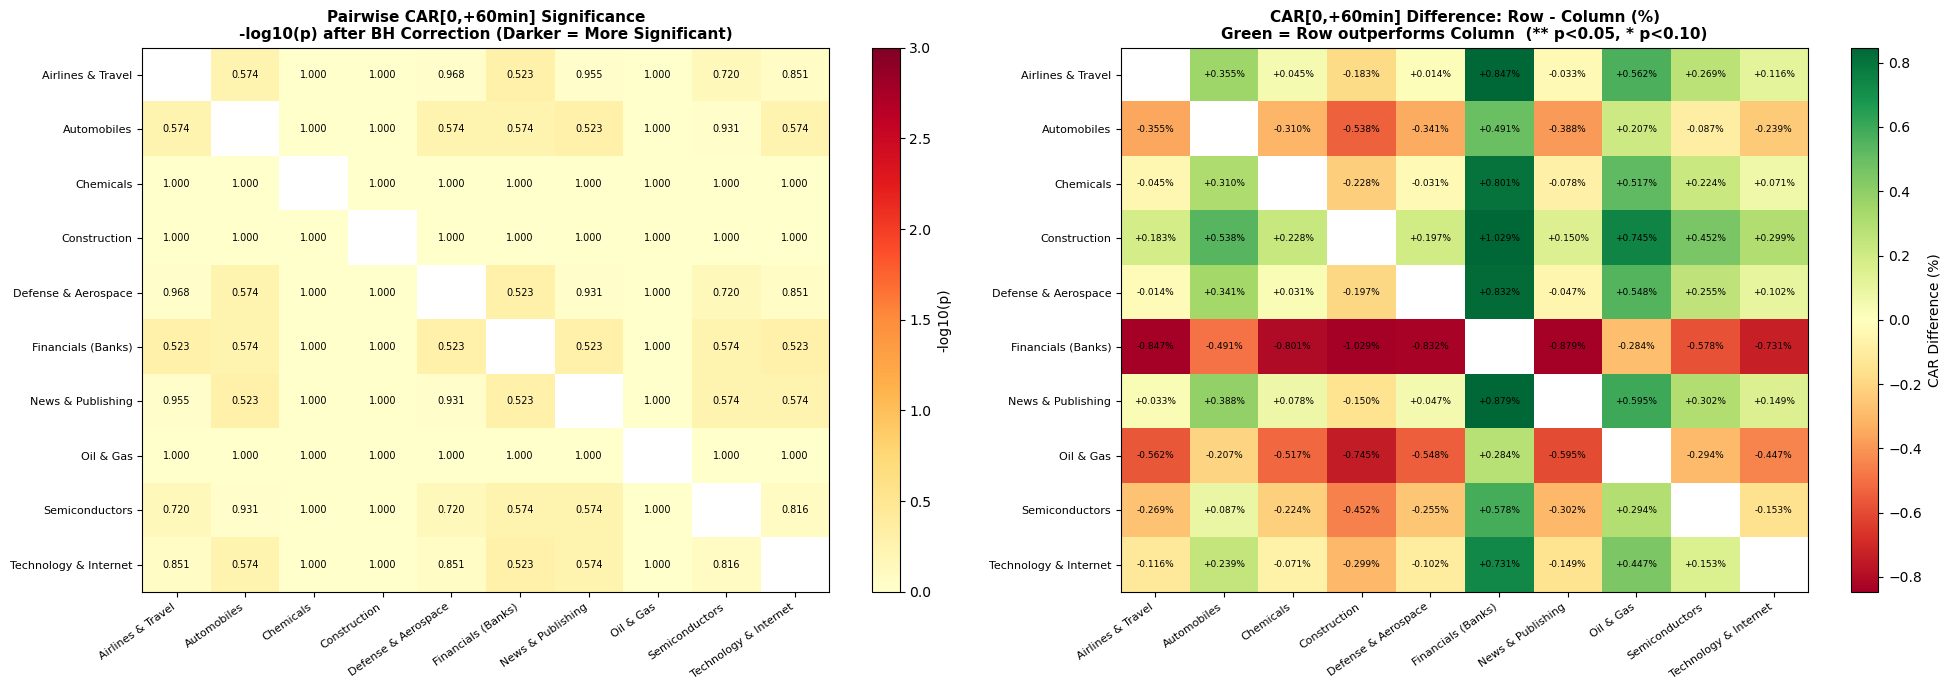

Saved: short_term_pairwise_matrix.png


In [10]:
n_ind   = len(PREFIXES)
p_mat   = np.ones((n_ind, n_ind))
d_mat   = np.zeros((n_ind, n_ind))
idx_map = {p: i for i, p in enumerate(PREFIXES)}
mean_c  = {p: np.mean(ind_cars[p])*100
            if len(ind_cars[p]) > 0 else np.nan for p in PREFIXES}

for _, row in pair_df.iterrows():
    i, j = idx_map[row['a']], idx_map[row['b']]
    pv   = row.get('p_bh', row['p_raw'])
    pv   = 1.0 if pd.isna(pv) else pv
    p_mat[i,j] = p_mat[j,i] = pv

for i, pi in enumerate(PREFIXES):
    for j, pj in enumerate(PREFIXES):
        if i != j:
            d_mat[i,j] = (mean_c.get(pi) or 0) - (mean_c.get(pj) or 0)

np.fill_diagonal(p_mat, np.nan)
np.fill_diagonal(d_mat, np.nan)

ylabs = [IND_LABELS[p] for p in PREFIXES]
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Left — significance
ax1  = axes[0]
logp = -np.log10(np.clip(p_mat, 1e-10, 1))
np.fill_diagonal(logp, np.nan)
im1  = ax1.imshow(logp, cmap='YlOrRd', aspect='auto', vmin=0, vmax=3)
for i in range(n_ind):
    for j in range(n_ind):
        if i == j: continue
        pv = p_mat[i,j]
        ax1.text(j, i, f'{pv:.3f}{sig_stars(pv)}',
                 ha='center', va='center', fontsize=7,
                 color='black' if logp[i,j] < 2 else 'white')
ax1.set_xticks(range(n_ind)); ax1.set_yticks(range(n_ind))
ax1.set_xticklabels(ylabs, rotation=35, ha='right', fontsize=8)
ax1.set_yticklabels(ylabs, fontsize=8)
ax1.set_title('Pairwise CAR[0,+60min] Significance\n'
              '-log10(p) after BH Correction (Darker = More Significant)',
              fontsize=11, fontweight='bold')
plt.colorbar(im1, ax=ax1, label='-log10(p)')

# Right — difference
ax2   = axes[1]
vmaxd = np.nanpercentile(np.abs(d_mat), 95)
im2   = ax2.imshow(d_mat, cmap='RdYlGn', aspect='auto',
                   vmin=-vmaxd, vmax=vmaxd)
for i in range(n_ind):
    for j in range(n_ind):
        if i == j: continue
        ax2.text(j, i,
                 f'{d_mat[i,j]:+.3f}%{sig_stars(p_mat[i,j])}',
                 ha='center', va='center', fontsize=6.5, color='black')
ax2.set_xticks(range(n_ind)); ax2.set_yticks(range(n_ind))
ax2.set_xticklabels(ylabs, rotation=35, ha='right', fontsize=8)
ax2.set_yticklabels(ylabs, fontsize=8)
ax2.set_title('CAR[0,+60min] Difference: Row - Column (%)\n'
              'Green = Row outperforms Column  (** p<0.05, * p<0.10)',
              fontsize=11, fontweight='bold')
plt.colorbar(im2, ax=ax2, label='CAR Difference (%)')

plt.tight_layout()
plt.savefig('short_term_pairwise_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: short_term_pairwise_matrix.png')

---
## Step 6: Short-term vs. Long-term Comparison

Loads `AAR_CAAR_treatment.csv` exported by `event_study_v2.ipynb`.  
Compares short-term CAAR[0,+60min] with long-term CAAR[day0,+5].

In [11]:
# Build short-term table
st_rows = []
for p in PREFIXES:
    df_r = results[p]
    c60  = df_r.loc[EVT_END,'CAAR']*100 if EVT_END in df_r.index else np.nan
    cp60 = df_r.loc[EVT_END,'CAAR_p']   if EVT_END in df_r.index else np.nan
    c30  = df_r.loc[30,'CAAR']*100       if 30      in df_r.index else np.nan
    cp30 = df_r.loc[30,'CAAR_p']         if 30      in df_r.index else np.nan
    n60  = int(df_r.loc[EVT_END,'N'])    if EVT_END in df_r.index else 0
    st_rows.append({'industry': IND_LABELS[p],
                    'ST_CAAR_30min': c30, 'ST_p_30': cp30,
                    'ST_CAAR_60min': c60, 'ST_p_60': cp60,
                    'N_short': n60})
st_df = pd.DataFrame(st_rows).set_index('industry')

# Load long-term
lt_loaded = False
try:
    lt_raw  = pd.read_csv(LONG_TERM_CSV)
    lt_t0   = lt_raw[lt_raw['t']==0].set_index('industry')['CAAR'].rename('LT_CAAR_day0')
    lt_t5   = lt_raw[lt_raw['t']==5].set_index('industry')['CAAR'].rename('LT_CAAR_day5')
    lt_p5   = lt_raw[lt_raw['t']==5].set_index('industry')['CAAR_p'].rename('LT_p_day5')
    compare = st_df.join([lt_t0, lt_t5, lt_p5], how='left')
    lt_loaded = True
    print('Long-term results loaded from:', LONG_TERM_CSV)
except FileNotFoundError:
    compare = st_df.copy()
    print(f'WARNING: {LONG_TERM_CSV} not found.')
    print('Run event_study_v2.ipynb first and save AAR_CAAR_treatment.csv')

print()
print('SHORT-TERM vs. LONG-TERM CAAR')
print('=' * 90)
for ind, row in compare.iterrows():
    line = (f"{ind:<35}  "
            f"ST[+60min]={row['ST_CAAR_60min']:>+8.4f}%{sig_stars(row['ST_p_60']):>3}")
    if lt_loaded:
        line += (f"   LT[day0]={row.get('LT_CAAR_day0',np.nan):>+8.4f}%"
                 f"   LT[day5]={row.get('LT_CAAR_day5',np.nan):>+8.4f}%"
                 f"{sig_stars(row.get('LT_p_day5',np.nan)):>3}")
    print(line)

Long-term results loaded from: AAR_CAAR_treatment.csv

SHORT-TERM vs. LONG-TERM CAAR
Airlines & Travel                    ST[+60min]= -0.0101%      LT[day0]= -0.1267%   LT[day5]= +0.8864%   
Automobiles                          ST[+60min]= -0.3654% **   LT[day0]= -0.1628%   LT[day5]= -0.1596%   
Chemicals                            ST[+60min]= -0.0553%      LT[day0]= -0.9958%   LT[day5]=    +nan%   
Construction                         ST[+60min]= +0.1727%      LT[day0]= -2.6887%   LT[day5]= -1.9200%   
Defense & Aerospace                  ST[+60min]= -0.0243%      LT[day0]= -0.2991%   LT[day5]= -0.9401%   
Financials (Banks)                   ST[+60min]= -0.8567%***   LT[day0]= -3.1131%   LT[day5]= -3.1047%   
News & Publishing                    ST[+60min]= +0.0227%      LT[day0]= -0.8475%   LT[day5]= -1.1788%***
Oil & Gas                            ST[+60min]= -0.5726%      LT[day0]= +0.6551%   LT[day5]=    +nan%   
Semiconductors                       ST[+60min]= -0.2789%      LT[d

### Figure 4 — Short vs. Long-term CAAR Grouped Bar Chart

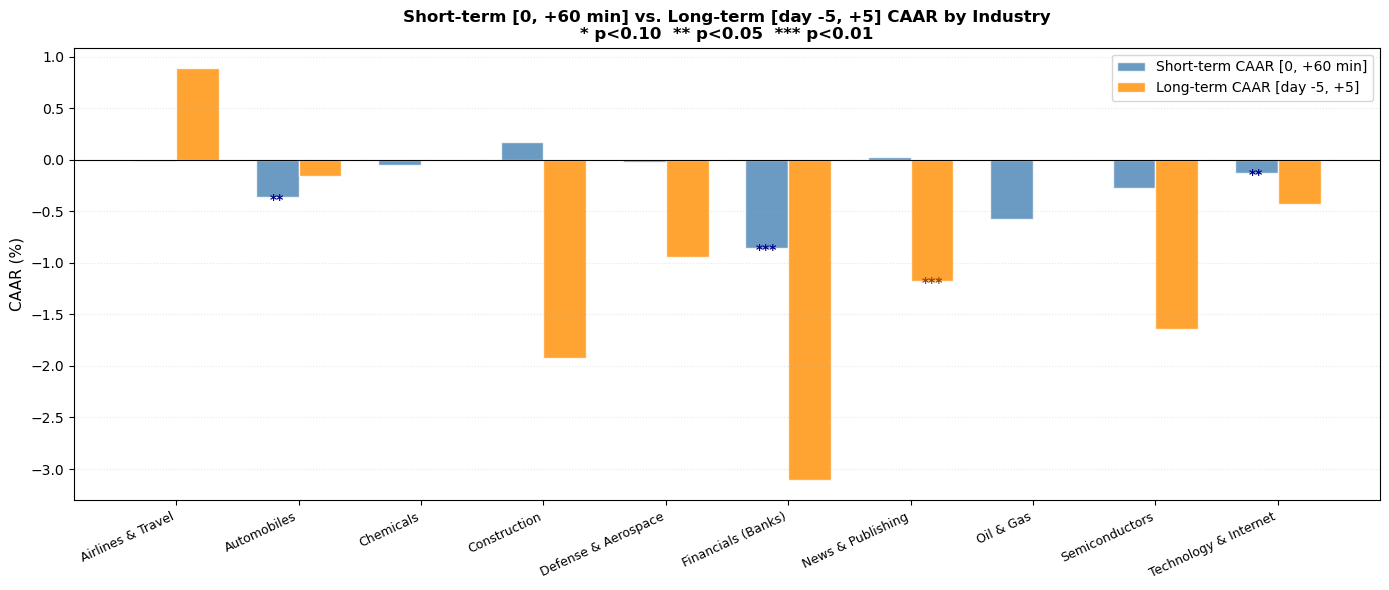

Saved: short_vs_long_term_CAAR.png


In [16]:
fig, ax = plt.subplots(figsize=(14, 6))
x, w    = np.arange(len(compare)), 0.35
st_vals = compare['ST_CAAR_60min'].values
st_pv   = compare['ST_p_60'].values

ax.bar(x - w/2, st_vals, w,
       label='Short-term CAAR [0, +60 min]',
       color='steelblue', alpha=0.80, edgecolor='white')

if lt_loaded:
    lt_vals = compare['LT_CAAR_day5'].values
    lt_pv   = compare['LT_p_day5'].values
    ax.bar(x + w/2, lt_vals, w,
           label='Long-term CAAR [day -5, +5]',
           color='darkorange', alpha=0.80, edgecolor='white')
    for i, (v, pv) in enumerate(zip(lt_vals, lt_pv)):
        if sig_stars(pv) and not np.isnan(v):
            ax.text(i+w/2, v+(0.03 if v>=0 else -0.06),
                    sig_stars(pv), ha='center', fontsize=10,
                    color='saddlebrown', fontweight='bold')

for i, (v, pv) in enumerate(zip(st_vals, st_pv)):
    if sig_stars(pv) and not np.isnan(v):
        ax.text(i-w/2, v+(0.03 if v>=0 else -0.06),
                sig_stars(pv), ha='center', fontsize=10,
                color='darkblue', fontweight='bold')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(compare.index, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('CAAR (%)', fontsize=11)
ax.set_title(
    'Short-term [0, +60 min] vs. Long-term [day -5, +5] CAAR by Industry\n'
    '* p<0.10  ** p<0.05  *** p<0.01',
    fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle=':')
plt.tight_layout()
plt.savefig('short_vs_long_term_CAAR.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: short_vs_long_term_CAAR.png')

---
## Step 7: Export

In [14]:
all_rows = []
for p in PREFIXES:
    df_r = results[p].reset_index().copy()
    df_r['industry'] = IND_LABELS[p]
    for col in ['AAR','CAAR','SE','CAAR_SE']:
        if col in df_r.columns:
            df_r[col] = df_r[col] * 100
    all_rows.append(df_r)

pd.concat(all_rows).to_csv('short_term_AAR_CAAR_results.csv', index=False)
pair_df.to_csv('short_term_pairwise.csv', index=False)
compare.reset_index().to_csv('short_vs_long_comparison.csv', index=False)

print('Exported:')
print('  short_term_AAR_CAAR_results.csv')
print('  short_term_pairwise.csv')
print('  short_vs_long_comparison.csv')

Exported:
  short_term_AAR_CAAR_results.csv
  short_term_pairwise.csv
  short_vs_long_comparison.csv
